Caricamento dati...
Gestione valori mancanti (Forward Fill)...
Inizio aggregazione per ciclo di volo...
Dataset trasformato: 8004 cicli di volo totali (righe).
Numero di Feature generate: 73


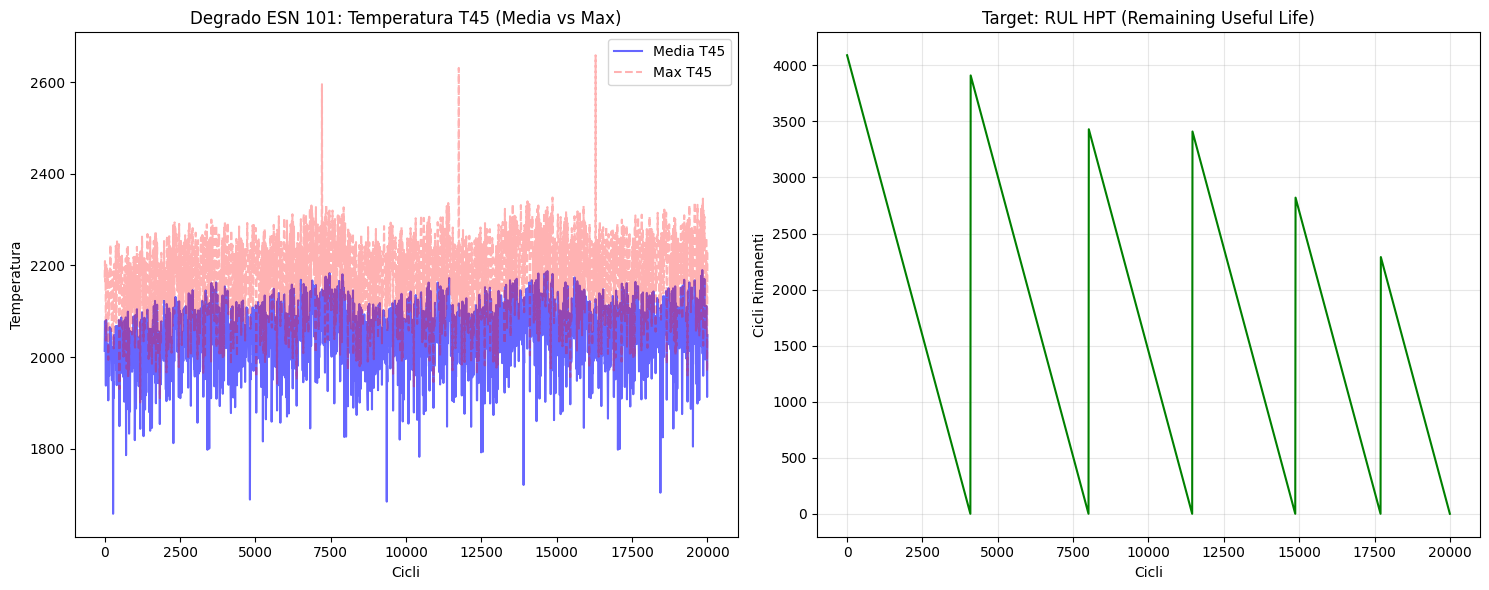

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CARICAMENTO E PULIZIA INIZIALE (CORRETTO)
# ==========================================
def load_and_clean_data(file_path):
    print("Caricamento dati...")
    df = pd.read_csv(file_path)
    
    # Ordiniamo per Motore -> Ciclo -> Snapshot
    df = df.sort_values(by=['ESN', 'Cycles_Since_New', 'Snapshot']).reset_index(drop=True)
    
    # GESTIONE NULL: Forward Fill per motore
    # Strategia: Usiamo 'transform' che mantiene allineamento e indici, senza toccare la colonna ESN
    print("Gestione valori mancanti (Forward Fill)...")
    
    # Identifichiamo le colonne da riempire (tutte tranne ESN)
    cols_to_fix = [col for col in df.columns if col != 'ESN']
    
    # Funzione di riempimento: avanti (ffill) e poi indietro (bfill) per i buchi iniziali
    fill_func = lambda x: x.ffill().bfill()
    
    # Applichiamo la trasformazione gruppo per gruppo
    df[cols_to_fix] = df.groupby('ESN')[cols_to_fix].transform(fill_func)
    
    return df

# Sostituisci con il nome del tuo file se diverso
df = load_and_clean_data('data/train/training_data.csv')

# ==========================================
# 2. FEATURE ENGINEERING (AGGREGAZIONE)
# ==========================================
print("Inizio aggregazione per ciclo di volo...")

# Definiamo le colonne dei sensori (escludiamo ID e Target per ora)
sensor_cols = [c for c in df.columns if c.startswith('Sensed')]

# Aggreghiamo le 8 righe (snapshot) in 1 riga unica per ciclo
# Calcoliamo: Media, Deviazione Standard, Max, Min per ogni sensore
aggregations = {col: ['mean', 'std', 'max', 'min'] for col in sensor_cols}

# Aggiungiamo anche il conteggio degli snapshot (potrebbe indicare anomalie se < 8)
aggregations['Snapshot'] = ['count']

# Eseguiamo l'aggregazione raggruppando per Motore e Ciclo
df_aggr = df.groupby(['ESN', 'Cycles_Since_New']).agg(aggregations)

# Appiattiamo i nomi delle colonne (es. Sensed_T25 -> mean diventa Sensed_T25_mean)
df_aggr.columns = ['_'.join(col).strip() for col in df_aggr.columns.values]
df_aggr = df_aggr.reset_index()

# ==========================================
# 3. RECUPERO TARGET E MERGE
# ==========================================
# I target sono identici per tutte le righe dello stesso ciclo, ne prendiamo uno a caso (es. il primo)
target_cols = ['Cycles_to_WW', 'Cycles_to_HPC_SV', 'Cycles_to_HPT_SV', 
               'Cumulative_WWs', 'Cumulative_HPC_SVs', 'Cumulative_HPT_SVs']
df_targets = df.groupby(['ESN', 'Cycles_Since_New'])[target_cols].first().reset_index()

# Uniamo tutto nel dataset finale (1 riga = 1 volo)
train_df = pd.merge(df_aggr, df_targets, on=['ESN', 'Cycles_Since_New'])

print(f"Dataset trasformato: {train_df.shape[0]} cicli di volo totali (righe).")
print(f"Numero di Feature generate: {train_df.shape[1]}")

# ==========================================
# 4. VISUALIZZAZIONE DI CONTROLLO
# ==========================================
# Mostriamo un esempio di come cambia la Temperatura T45 media nel tempo per il motore 101
subset = train_df[train_df['ESN'] == 101]

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.plot(subset['Cycles_Since_New'], subset['Sensed_T45_mean'], label='Media T45', color='blue', alpha=0.6)
plt.plot(subset['Cycles_Since_New'], subset['Sensed_T45_max'], label='Max T45', color='red', alpha=0.3, linestyle='--')
plt.title('Degrado ESN 101: Temperatura T45 (Media vs Max)')
plt.xlabel('Cicli')
plt.ylabel('Temperatura')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(subset['Cycles_Since_New'], subset['Cycles_to_HPT_SV'], color='green')
plt.title('Target: RUL HPT (Remaining Useful Life)')
plt.xlabel('Cicli')
plt.ylabel('Cicli Rimanenti')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Salva il dataset processato se vuoi
train_df.to_csv('processed_train_data.csv', index=False)

### XGBOOST e RANDOM FOREST

XGBOOST sembra essere adatto per motori sani, tentando di correggere il 104 porta a risulati assurdi. per tale motivo introduciamo il rf

Caricamento data_elaborated/train/train_with_residuals.csv...
Aggregazione Ciclica...
Calcolo Feature Cumulative (Anti-Rumore)...
Feature Totali: 17

>>> TRAINING TARGET: Cycles_to_HPT_SV
Fold 1: Score = 43.7282


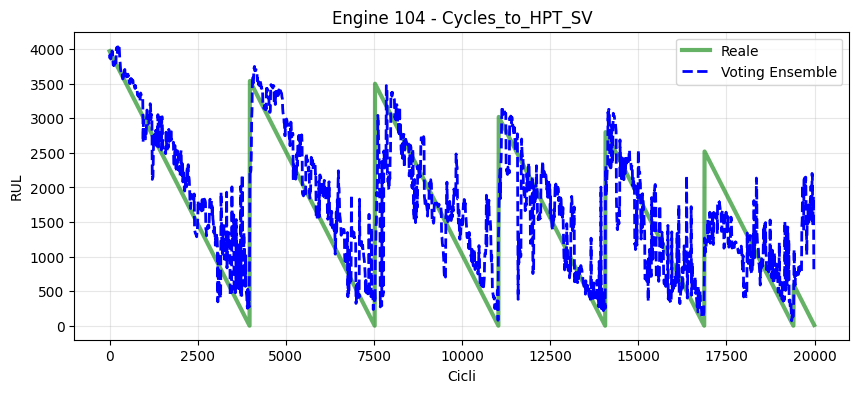

Fold 2: Score = 19.7141
Fold 3: Score = 21.3744
Fold 4: Score = 11.7321
MEDIA SCORE Cycles_to_HPT_SV: 24.1372

>>> TRAINING TARGET: Cycles_to_HPC_SV
Fold 1: Score = 32.5878


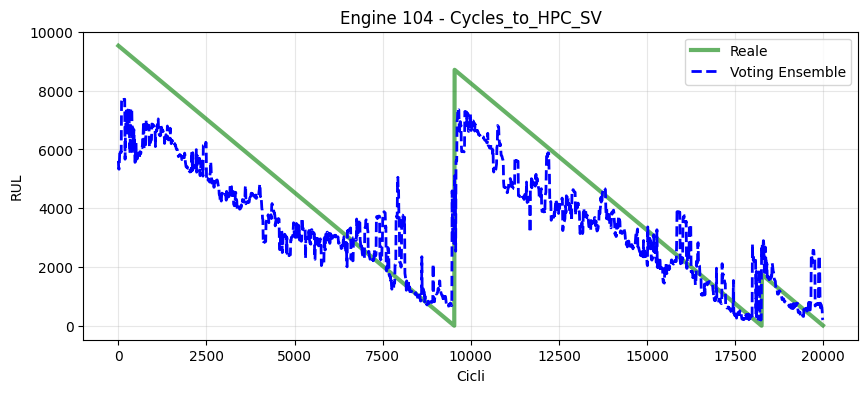

Fold 2: Score = 23.0454
Fold 3: Score = 7.3780
Fold 4: Score = 13.8050
MEDIA SCORE Cycles_to_HPC_SV: 19.2040

>>> TRAINING TARGET: Cycles_to_WW
Fold 1: Score = 43.1319


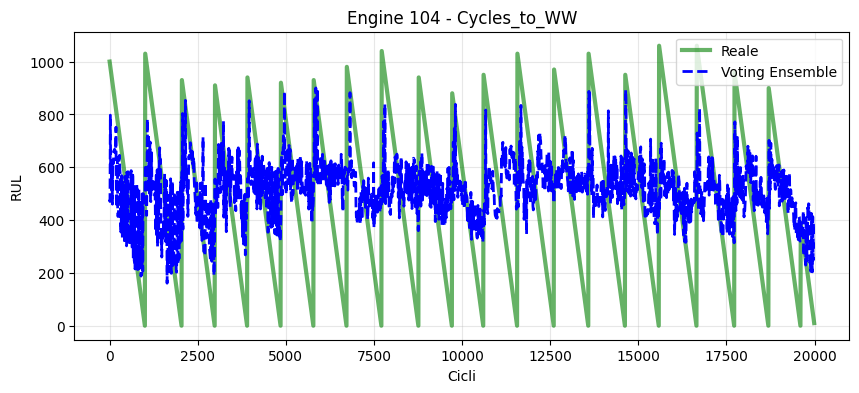

Fold 2: Score = 27.6344
Fold 3: Score = 23.7759
Fold 4: Score = 28.6480
MEDIA SCORE Cycles_to_WW: 30.7976

SCORE TOTALE COMPETIZIONE: 24.7129


In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestRegressor, VotingRegressor

# ==========================================
# CONFIGURAZIONE
# ==========================================
FILE_INPUT = 'data_elaborated/train/train_with_residuals.csv' 

# ==========================================
# 1. FUNZIONI SCORE & PLOT
# ==========================================
def get_score(y_true, y_pred, target_name):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    error = y_pred - y_true
    alpha = 0.01 
    max_val = np.max(y_true) if len(y_true) > 0 else 1
    
    beta = 1/max_val if 'WW' in target_name else 2/max_val 
    w = np.where(error >= 0, 2 / (1 + alpha * y_true), 1 / (1 + alpha * y_true))
    return np.mean(w * (error**2) * beta)

def plot_single_engine(df_result, engine_id, target_name):
    df_eng = df_result[df_result['ESN'] == engine_id].copy()
    df_eng = df_eng.sort_values('Cycles_Since_New')
    
    plt.figure(figsize=(10, 4))
    plt.plot(df_eng['Cycles_Since_New'], df_eng['RUL_Real'], label='Reale', color='green', linewidth=3, alpha=0.6)
    plt.plot(df_eng['Cycles_Since_New'], df_eng['RUL_Pred'], label='Voting Ensemble', color='blue', linewidth=2, linestyle='--')
    plt.title(f'Engine {engine_id} - {target_name}', fontsize=12)
    plt.xlabel('Cicli'); plt.ylabel('RUL'); plt.legend(); plt.grid(True, alpha=0.3)
    plt.show()

# ==========================================
# 2. CARICAMENTO DATI (CUMULATIVE LOGIC)
# ==========================================
# Manteniamo la logica cumulativa perché è fisica pura e aiuta qualsiasi modello
def load_data_robust(path):
    print(f"Caricamento {path}...")
    try:
        df = pd.read_csv(path)
    except FileNotFoundError:
        print("ERRORE: File non trovato."); return None, []
        
    available_targets = [t for t in ['Cycles_to_HPT_SV', 'Cycles_to_HPC_SV', 'Cycles_to_WW'] if t in df.columns]

    # Aggregazione
    print("Aggregazione Ciclica...")
    res_cols = [c for c in df.columns if '_res' in c]
    if df.duplicated(subset=['ESN', 'Cycles_Since_New']).any():
        agg_dict = {col: ['mean'] for col in res_cols} 
        agg_dict.update({col: ['mean'] for col in ['Sensed_Mach', 'Sensed_Altitude']})
        if 'Cumulative_WWs' in df.columns: agg_dict['Cumulative_WWs'] = ['max']
            
        df_aggr = df.groupby(['ESN', 'Cycles_Since_New']).agg(agg_dict)
        df_aggr.columns = ['_'.join(col).strip() for col in df_aggr.columns.values]
        df_aggr = df_aggr.reset_index()
        targets_df = df.groupby(['ESN', 'Cycles_Since_New'])[available_targets].first().reset_index()
        df = pd.merge(df_aggr, targets_df, on=['ESN', 'Cycles_Since_New'])

    # Feature Engineering (Cumulativo)
    print("Calcolo Feature Cumulative (Anti-Rumore)...")
    cols_to_process = [c for c in df.columns if '_res' in c]
    for col in cols_to_process:
        df[f'{col}_cumsum'] = df.groupby('ESN')[col].transform(lambda x: x.cumsum())
        df[f'{col}_roll10'] = df.groupby('ESN')[col].transform(lambda x: x.rolling(10, min_periods=1).mean())
        # Aggiungiamo Slope (Tendenza)
        df[f'{col}_slope'] = df.groupby('ESN')[f'{col}_roll10'].transform(lambda x: x.diff().fillna(0))

    df = df.bfill().ffill()
    df = df.sort_values(['ESN', 'Cycles_Since_New']).reset_index(drop=True)
    return df, available_targets

# ==========================================
# 3. TRAINING: VOTING REGRESSOR (XGB + RF)
# ==========================================
df_proc, targets_to_train = load_data_robust(FILE_INPUT)

if df_proc is not None:
    groups = df_proc['ESN']
    meta = df_proc[['ESN', 'Cycles_Since_New']]
    final_global_score = []

    # Usiamo le feature cumulative che funzionano meglio
    feats = [c for c in df_proc.columns if 'cumsum' in c or 'roll10' in c or 'slope' in c] 
    feats += ['Cycles_Since_New']
    if 'Cumulative_WWs_max' in df_proc.columns: feats += ['Cumulative_WWs_max']
    elif 'Cumulative_WWs' in df_proc.columns: feats += ['Cumulative_WWs']
    
    print(f"Feature Totali: {len(feats)}")

    for target_col in targets_to_train:
        print(f"\n>>> TRAINING TARGET: {target_col}")
        
        mask = df_proc[target_col].notna()
        X = df_proc.loc[mask, feats]
        y = df_proc.loc[mask, target_col]
        curr_groups = groups.loc[mask]
        
        gkf = GroupKFold(n_splits=4)
        target_scores = []
        
        for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=curr_groups)):
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
            
            # --- DEFINIZIONE MODELLI ---
            
            # 1. XGBoost (Il "Cecchino": Preciso ma sensibile)
            xgb_model = xgb.XGBRegressor(
                n_estimators=500, learning_rate=0.02, max_depth=5, 
                subsample=0.7, colsample_bytree=0.7, 
                objective='reg:squarederror', n_jobs=-1, random_state=42
            )
            
            # 2. Random Forest (Il "Carro Armato": Robusto e stabile)
            # Nota: min_samples_leaf=5 aiuta a ignorare i singoli picchi rumorosi (outlier)
            rf_model = RandomForestRegressor(
                n_estimators=100,       # Numero di alberi
                max_depth=10,           # Limitiamo la profondità per evitare overfitting
                min_samples_leaf=10,    # FONDAMENTALE per il Motore 104: deve avere almeno 10 conferme per decidere
                n_jobs=-1, random_state=42
            )
            
            # 3. Voting Regressor (La Democrazia)
            # Mettiamo insieme i due modelli.
            voting_model = VotingRegressor(
                estimators=[('xgb', xgb_model), ('rf', rf_model)],
                weights=[0.5, 0.5] # Peso uguale. Puoi provare [0.3, 0.7] se il 104 è ancora un problema.
            )
            
            # Addestramento
            # Nota: Random Forest non supporta sample_weight nel Voting facilmente in tutte le versioni sklearn, 
            # ma .fit() del Voting lo passa ai sotto-modelli se supportato.
            # Per sicurezza addestriamo senza pesi complessi o usiamo pesi semplici.
            # Qui usiamo fit diretto.
            voting_model.fit(X_train, y_train)
            
            preds = voting_model.predict(X_val)
            
            # Bias Pessimista (Sempre utile)
            preds_safe = (preds * 0.95) - 10
            
            score = get_score(y_val, preds_safe, target_col)
            target_scores.append(score)
            
            print(f"Fold {fold+1}: Score = {score:.4f}")
            
            if fold == 0: # Plot Engine 104
                df_res = meta.iloc[val_idx].copy()
                df_res['RUL_Real'] = y_val.values
                df_res['RUL_Pred'] = preds_safe
                plot_single_engine(df_res, df_res['ESN'].iloc[0], target_col)

        mean_score = np.mean(target_scores)
        final_global_score.append(mean_score)
        print(f"MEDIA SCORE {target_col}: {mean_score:.4f}")

    print(f"\n========================================")
    print(f"SCORE TOTALE COMPETIZIONE: {np.mean(final_global_score):.4f}")
    print(f"========================================")

Caricamento data_elaborated/train/train_with_residuals.csv...
Aggregazione Ciclica...
Calcolo Feature Cumulative...
Feature Totali: 17

>>> TRAINING TARGET: Cycles_to_HPT_SV
Fold 1: Score = 18.3246


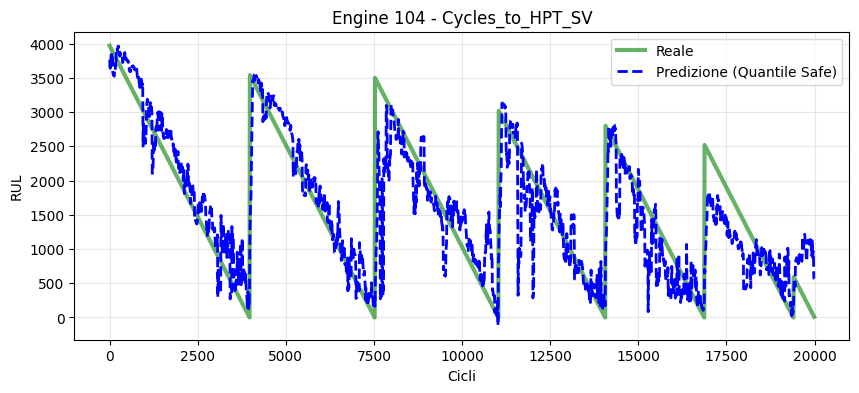

Fold 2: Score = 11.1726
Fold 3: Score = 7.9583
Fold 4: Score = 8.8121
MEDIA SCORE Cycles_to_HPT_SV: 11.5669

>>> TRAINING TARGET: Cycles_to_HPC_SV
Fold 1: Score = 19.8971


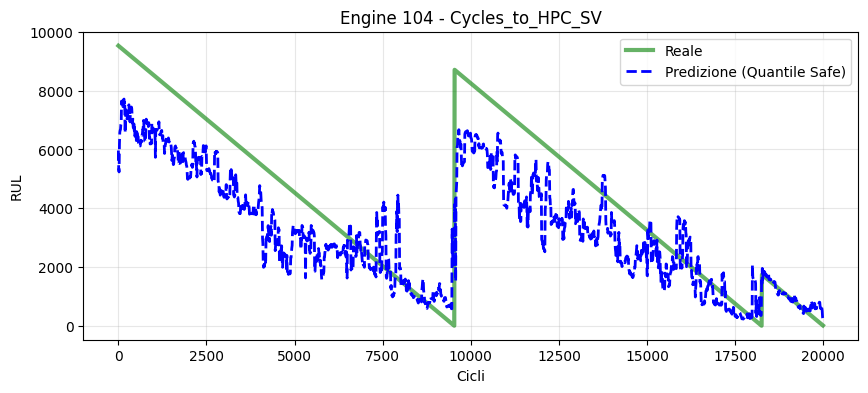

Fold 2: Score = 17.5518
Fold 3: Score = 8.2400
Fold 4: Score = 8.9150
MEDIA SCORE Cycles_to_HPC_SV: 13.6510

>>> TRAINING TARGET: Cycles_to_WW
Fold 1: Score = 24.9565


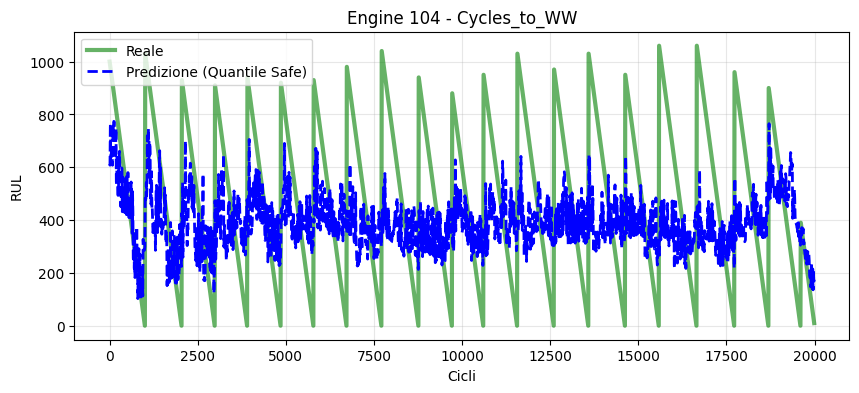

Fold 2: Score = 17.5372
Fold 3: Score = 15.4236
Fold 4: Score = 16.5796
MEDIA SCORE Cycles_to_WW: 18.6242

SCORE TOTALE COMPETIZIONE: 14.6140


In [3]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import GradientBoostingRegressor

# ==========================================
# CONFIGURAZIONE
# ==========================================
FILE_INPUT = 'data_elaborated/train/train_with_residuals.csv' 

# ==========================================
# 1. FUNZIONI
# ==========================================
def get_score(y_true, y_pred, target_name):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    error = y_pred - y_true
    alpha = 0.01 
    max_val = np.max(y_true) if len(y_true) > 0 else 1
    
    beta = 1/max_val if 'WW' in target_name else 2/max_val 
    w = np.where(error >= 0, 2 / (1 + alpha * y_true), 1 / (1 + alpha * y_true))
    return np.mean(w * (error**2) * beta)

def plot_single_engine(df_result, engine_id, target_name):
    df_eng = df_result[df_result['ESN'] == engine_id].copy()
    df_eng = df_eng.sort_values('Cycles_Since_New')
    
    plt.figure(figsize=(10, 4))
    plt.plot(df_eng['Cycles_Since_New'], df_eng['RUL_Real'], label='Reale', color='green', linewidth=3, alpha=0.6)
    plt.plot(df_eng['Cycles_Since_New'], df_eng['RUL_Pred'], label='Predizione (Quantile Safe)', color='blue', linewidth=2, linestyle='--')
    plt.title(f'Engine {engine_id} - {target_name}', fontsize=12)
    plt.xlabel('Cicli'); plt.ylabel('RUL'); plt.legend(); plt.grid(True, alpha=0.3)
    plt.show()

# ==========================================
# 2. CARICAMENTO DATI (CUMULATIVE ROBUST)
# ==========================================
def load_data_robust(path):
    print(f"Caricamento {path}...")
    try:
        df = pd.read_csv(path)
    except FileNotFoundError:
        print("ERRORE: File non trovato."); return None, []
        
    available_targets = [t for t in ['Cycles_to_HPT_SV', 'Cycles_to_HPC_SV', 'Cycles_to_WW'] if t in df.columns]

    # Aggregazione
    print("Aggregazione Ciclica...")
    res_cols = [c for c in df.columns if '_res' in c]
    if df.duplicated(subset=['ESN', 'Cycles_Since_New']).any():
        agg_dict = {col: ['mean'] for col in res_cols} 
        agg_dict.update({col: ['mean'] for col in ['Sensed_Mach', 'Sensed_Altitude']})
        if 'Cumulative_WWs' in df.columns: agg_dict['Cumulative_WWs'] = ['max']
            
        df_aggr = df.groupby(['ESN', 'Cycles_Since_New']).agg(agg_dict)
        df_aggr.columns = ['_'.join(col).strip() for col in df_aggr.columns.values]
        df_aggr = df_aggr.reset_index()
        targets_df = df.groupby(['ESN', 'Cycles_Since_New'])[available_targets].first().reset_index()
        df = pd.merge(df_aggr, targets_df, on=['ESN', 'Cycles_Since_New'])

    # Feature Engineering (Cumulativo - Logica del Paper)
    print("Calcolo Feature Cumulative...")
    cols_to_process = [c for c in df.columns if '_res' in c]
    for col in cols_to_process:
        df[f'{col}_cumsum'] = df.groupby('ESN')[col].transform(lambda x: x.cumsum())
        df[f'{col}_roll10'] = df.groupby('ESN')[col].transform(lambda x: x.rolling(10, min_periods=1).mean())
        # Slope per intercettare il crollo finale
        df[f'{col}_slope'] = df.groupby('ESN')[f'{col}_roll10'].transform(lambda x: x.diff().fillna(0))

    df = df.bfill().ffill()
    df = df.sort_values(['ESN', 'Cycles_Since_New']).reset_index(drop=True)
    return df, available_targets

# ==========================================
# 3. TRAINING: HYBRID QUANTILE ENSEMBLE
# ==========================================
df_proc, targets_to_train = load_data_robust(FILE_INPUT)

if df_proc is not None:
    groups = df_proc['ESN']
    meta = df_proc[['ESN', 'Cycles_Since_New']]
    final_global_score = []

    # Feature Cumulative
    feats = [c for c in df_proc.columns if 'cumsum' in c or 'roll10' in c or 'slope' in c] 
    feats += ['Cycles_Since_New']
    if 'Cumulative_WWs_max' in df_proc.columns: feats += ['Cumulative_WWs_max']
    elif 'Cumulative_WWs' in df_proc.columns: feats += ['Cumulative_WWs']
    
    print(f"Feature Totali: {len(feats)}")

    for target_col in targets_to_train:
        print(f"\n>>> TRAINING TARGET: {target_col}")
        
        mask = df_proc[target_col].notna()
        X = df_proc.loc[mask, feats]
        y = df_proc.loc[mask, target_col]
        curr_groups = groups.loc[mask]
        
        gkf = GroupKFold(n_splits=4)
        target_scores = []
        
        for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=curr_groups)):
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
            
            # 1. MODELLO "ACCURATEZZA" (XGBoost Standard)
            # Cerca di indovinare la media esatta. È preciso ma rischioso.
            model_acc = xgb.XGBRegressor(
                n_estimators=500, learning_rate=0.02, max_depth=5,
                subsample=0.7, colsample_bytree=0.7, objective='reg:squarederror',
                n_jobs=-1, random_state=42
            )
            model_acc.fit(X_train, y_train)
            pred_acc = model_acc.predict(X_val)
            
            # 2. MODELLO "SICUREZZA" (GradientBoosting Quantile)
            # Cerca il valore sotto il quale c'è solo il 15% di probabilità (Molto pessimista).
            # alpha=0.15 significa: "Sii sicuro all'85% di non sovrastimare".
            model_safe = GradientBoostingRegressor(
                loss='quantile', alpha=0.15,
                n_estimators=200, max_depth=4, learning_rate=0.05,
                random_state=42
            )
            model_safe.fit(X_train, y_train)
            pred_safe_raw = model_safe.predict(X_val)
            
            # 3. ENSEMBLE (Il meglio dei due mondi)
            # Prendiamo il 40% dall'accurato e il 60% dal pessimista.
            # Questo sostituisce il bias manuale con una stima statistica.
            preds_final = (0.4 * pred_acc) + (0.6 * pred_safe_raw)
            
            # Un piccolissimo margine fisso finale per i casi limite (vicino allo zero)
            preds_final = preds_final - 5 
            
            score = get_score(y_val, preds_final, target_col)
            target_scores.append(score)
            
            print(f"Fold {fold+1}: Score = {score:.4f}")
            
            if fold == 0: 
                df_res = meta.iloc[val_idx].copy()
                df_res['RUL_Real'] = y_val.values
                df_res['RUL_Pred'] = preds_final
                plot_single_engine(df_res, df_res['ESN'].iloc[0], target_col)

        mean_score = np.mean(target_scores)
        final_global_score.append(mean_score)
        print(f"MEDIA SCORE {target_col}: {mean_score:.4f}")

    print(f"\n========================================")
    print(f"SCORE TOTALE COMPETIZIONE: {np.mean(final_global_score):.4f}")
    print(f"========================================")

In [4]:
# ==========================================
# CELLA DI DIAGNOSI: GAP ANALYSIS (Train vs Validation)
# ==========================================
# Assicurati di aver eseguito la cella precedente per avere df_proc in memoria.

print(f"\n--- AVVIO DIAGNOSI APPROFONDITA (GAP ANALYSIS) ---")

# Ridefiniamo le feature per sicurezza (nel caso fossero state modificate)
feats = [c for c in df_proc.columns if 'cumsum' in c or 'roll10' in c or 'slope' in c] 
feats += ['Cycles_Since_New']
if 'Cumulative_WWs_max' in df_proc.columns: feats += ['Cumulative_WWs_max']
elif 'Cumulative_WWs' in df_proc.columns: feats += ['Cumulative_WWs']

groups = df_proc['ESN']

for target_col in targets_to_train:
    print(f"\n" + "="*50)
    print(f" ANALISI TARGET: {target_col}")
    print("="*50)
    
    mask = df_proc[target_col].notna()
    X = df_proc.loc[mask, feats]
    y = df_proc.loc[mask, target_col]
    curr_groups = groups.loc[mask]
    
    gkf = GroupKFold(n_splits=4)
    
    train_scores = []
    val_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=curr_groups)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        # --- 1. RIESECUZIONE TRAINING (Esattamente come nel modello finale) ---
        
        # Modello Accuratezza (XGBoost)
        model_acc = xgb.XGBRegressor(
            n_estimators=500, learning_rate=0.02, max_depth=5,
            subsample=0.7, colsample_bytree=0.7, objective='reg:squarederror',
            n_jobs=-1, random_state=42
        )
        model_acc.fit(X_train, y_train)
        
        # Modello Sicurezza (GradientBoosting Quantile)
        model_safe = GradientBoostingRegressor(
            loss='quantile', alpha=0.15,
            n_estimators=200, max_depth=4, learning_rate=0.05,
            random_state=42
        )
        model_safe.fit(X_train, y_train)
        
        # --- 2. PREDIZIONE DOPPIA (Train vs Val) ---
        
        # A. VALIDATION (Il test reale)
        p_acc_val = model_acc.predict(X_val)
        p_safe_val = model_safe.predict(X_val)
        pred_val = (0.4 * p_acc_val) + (0.6 * p_safe_val) - 5
        score_val = get_score(y_val, pred_val, target_col)
        
        # B. TRAINING (Il test "memoria")
        p_acc_train = model_acc.predict(X_train)
        p_safe_train = model_safe.predict(X_train)
        pred_train = (0.4 * p_acc_train) + (0.6 * p_safe_train) - 5
        score_train = get_score(y_train, pred_train, target_col)
        
        train_scores.append(score_train)
        val_scores.append(score_val)
        
        # --- 3. ANALISI GAP ---
        gap = score_val - score_train
        
        # Logica semaforo
        if gap < 5: status = "🟢 OTTIMO (Robusto)"
        elif gap < 12: status = "🟡 OK (Accettabile)"
        else: status = "🔴 ATTENZIONE (Overfitting)"
        
        print(f"Fold {fold+1}: Train={score_train:.2f} | Val={score_val:.2f} | GAP={gap:.2f} -> {status}")

    avg_train = np.mean(train_scores)
    avg_val = np.mean(val_scores)
    
    print("-" * 30)
    print(f"MEDIA {target_col}:")
    print(f"  Train Score: {avg_train:.2f}")
    print(f"  Val Score:   {avg_val:.2f}")
    print(f"  GAP MEDIO:   {avg_val - avg_train:.2f}")


--- AVVIO DIAGNOSI APPROFONDITA (GAP ANALYSIS) ---

 ANALISI TARGET: Cycles_to_HPT_SV
Fold 1: Train=1.44 | Val=18.32 | GAP=16.88 -> 🔴 ATTENZIONE (Overfitting)
Fold 2: Train=2.02 | Val=11.17 | GAP=9.16 -> 🟡 OK (Accettabile)
Fold 3: Train=1.76 | Val=7.96 | GAP=6.20 -> 🟡 OK (Accettabile)
Fold 4: Train=1.79 | Val=8.81 | GAP=7.03 -> 🟡 OK (Accettabile)
------------------------------
MEDIA Cycles_to_HPT_SV:
  Train Score: 1.75
  Val Score:   11.57
  GAP MEDIO:   9.82

 ANALISI TARGET: Cycles_to_HPC_SV
Fold 1: Train=1.01 | Val=19.90 | GAP=18.89 -> 🔴 ATTENZIONE (Overfitting)
Fold 2: Train=1.30 | Val=17.55 | GAP=16.25 -> 🔴 ATTENZIONE (Overfitting)
Fold 3: Train=1.87 | Val=8.24 | GAP=6.37 -> 🟡 OK (Accettabile)
Fold 4: Train=1.90 | Val=8.92 | GAP=7.01 -> 🟡 OK (Accettabile)
------------------------------
MEDIA Cycles_to_HPC_SV:
  Train Score: 1.52
  Val Score:   13.65
  GAP MEDIO:   12.13

 ANALISI TARGET: Cycles_to_WW
Fold 1: Train=7.58 | Val=24.96 | GAP=17.38 -> 🔴 ATTENZIONE (Overfitting)
Fold 2

### OVERFITTA NON VA BENE

In [5]:
# ==========================================
# DIAGNOSI: GAP ANALYSIS CON REGOLARIZZAZIONE FORTE
# ==========================================
# (Assicurati di avere df_proc in memoria)

print(f"\n--- GAP ANALYSIS: VERSIONE 'ANTI-OVERFITTING' ---")

# Ridefiniamo le feature
feats = [c for c in df_proc.columns if 'cumsum' in c or 'roll10' in c or 'slope' in c] 
feats += ['Cycles_Since_New']
if 'Cumulative_WWs_max' in df_proc.columns: feats += ['Cumulative_WWs_max']
elif 'Cumulative_WWs' in df_proc.columns: feats += ['Cumulative_WWs']

groups = df_proc['ESN']

for target_col in targets_to_train:
    print(f"\n" + "="*50)
    print(f" ANALISI TARGET: {target_col}")
    print("="*50)
    
    mask = df_proc[target_col].notna()
    X = df_proc.loc[mask, feats]
    y = df_proc.loc[mask, target_col]
    curr_groups = groups.loc[mask]
    
    gkf = GroupKFold(n_splits=4)
    
    train_scores = []
    val_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=curr_groups)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        # --- MODIFICHE DRASTICHE ANTI-OVERFITTING ---
        
        # 1. XGBoost (Accuratezza) -> Reso molto più "rigido"
        model_acc = xgb.XGBRegressor(
            n_estimators=600, 
            learning_rate=0.01,   # Rallentiamo l'apprendimento
            max_depth=3,          # ALBERI BASSI (Era 5) -> Meno memoria
            min_child_weight=30,  # FILTRO RUMORE (Era 1) -> Ignora i picchi isolati
            subsample=0.5,        # Guarda meno dati per volta (Più varietà)
            colsample_bytree=0.5, # Guarda meno feature per volta
            reg_alpha=5.0,        # L1 Regularization (Feature Selection brutale)
            reg_lambda=5.0,       # L2 Regularization
            objective='reg:squarederror',
            n_jobs=-1, random_state=42
        )
        model_acc.fit(X_train, y_train)
        
        # 2. GradientBoosting (Sicurezza) -> Reso elementare
        model_safe = GradientBoostingRegressor(
            loss='quantile', alpha=0.15,
            n_estimators=150,     # Meno alberi
            max_depth=2,          # BASSISSIMO (Quasi una linea retta)
            min_samples_leaf=30,  # Deve avere tante conferme per decidere
            learning_rate=0.05,
            random_state=42
        )
        model_safe.fit(X_train, y_train)
        
        # --- PREDIZIONI ---
        # Validation
        p_acc_val = model_acc.predict(X_val)
        p_safe_val = model_safe.predict(X_val)
        pred_val = (0.4 * p_acc_val) + (0.6 * p_safe_val) - 5
        score_val = get_score(y_val, pred_val, target_col)
        
        # Training
        p_acc_train = model_acc.predict(X_train)
        p_safe_train = model_safe.predict(X_train)
        pred_train = (0.4 * p_acc_train) + (0.6 * p_safe_train) - 5
        score_train = get_score(y_train, pred_train, target_col)
        
        train_scores.append(score_train)
        val_scores.append(score_val)
        
        gap = score_val - score_train
        
        # Semaforo più severo
        if gap < 6: status = "🟢 OTTIMO"
        elif gap < 10: status = "🟡 OK"
        else: status = "🔴 OVERFITTING"
        
        print(f"Fold {fold+1}: Train={score_train:.2f} | Val={score_val:.2f} | GAP={gap:.2f} -> {status}")

    avg_train = np.mean(train_scores)
    avg_val = np.mean(val_scores)
    
    print("-" * 30)
    print(f"MEDIA {target_col}:")
    print(f"  Train Score: {avg_train:.2f}")
    print(f"  Val Score:   {avg_val:.2f}")
    print(f"  GAP MEDIO:   {avg_val - avg_train:.2f}")


--- GAP ANALYSIS: VERSIONE 'ANTI-OVERFITTING' ---

 ANALISI TARGET: Cycles_to_HPT_SV
Fold 1: Train=4.52 | Val=18.09 | GAP=13.56 -> 🔴 OVERFITTING
Fold 2: Train=5.79 | Val=13.72 | GAP=7.93 -> 🟡 OK
Fold 3: Train=5.97 | Val=9.48 | GAP=3.51 -> 🟢 OTTIMO
Fold 4: Train=5.88 | Val=10.26 | GAP=4.37 -> 🟢 OTTIMO
------------------------------
MEDIA Cycles_to_HPT_SV:
  Train Score: 5.54
  Val Score:   12.89
  GAP MEDIO:   7.34

 ANALISI TARGET: Cycles_to_HPC_SV
Fold 1: Train=3.82 | Val=22.09 | GAP=18.26 -> 🔴 OVERFITTING
Fold 2: Train=6.16 | Val=14.98 | GAP=8.83 -> 🟡 OK
Fold 3: Train=6.85 | Val=9.19 | GAP=2.34 -> 🟢 OTTIMO
Fold 4: Train=6.98 | Val=9.20 | GAP=2.22 -> 🟢 OTTIMO
------------------------------
MEDIA Cycles_to_HPC_SV:
  Train Score: 5.95
  Val Score:   13.86
  GAP MEDIO:   7.91

 ANALISI TARGET: Cycles_to_WW
Fold 1: Train=14.68 | Val=22.26 | GAP=7.58 -> 🟡 OK
Fold 2: Train=15.08 | Val=18.68 | GAP=3.60 -> 🟢 OTTIMO
Fold 3: Train=15.23 | Val=17.41 | GAP=2.19 -> 🟢 OTTIMO
Fold 4: Train=15.28 | 

In [6]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import GradientBoostingRegressor

# ==========================================
# GAP ANALYSIS: VERSIONE "DRACONIANA" (Massima Generalizzazione)
# ==========================================
# Assumiamo che df_proc sia già caricato dalla cella precedente

print(f"\n--- GAP ANALYSIS: VERSIONE 'DRACONIANA' ---")

# Ridefiniamo le feature
feats = [c for c in df_proc.columns if 'cumsum' in c or 'roll10' in c or 'slope' in c] 
feats += ['Cycles_Since_New']
if 'Cumulative_WWs_max' in df_proc.columns: feats += ['Cumulative_WWs_max']
elif 'Cumulative_WWs' in df_proc.columns: feats += ['Cumulative_WWs']

groups = df_proc['ESN']

# Testiamo solo sui target critici per vedere l'effetto
targets_to_test = ['Cycles_to_HPT_SV', 'Cycles_to_HPC_SV', 'Cycles_to_WW']

for target_col in targets_to_test:
    print(f"\n" + "="*50)
    print(f" ANALISI TARGET: {target_col}")
    print("="*50)
    
    mask = df_proc[target_col].notna()
    X = df_proc.loc[mask, feats]
    y = df_proc.loc[mask, target_col]
    curr_groups = groups.loc[mask]
    
    gkf = GroupKFold(n_splits=4)
    
    train_scores = []
    val_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=curr_groups)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        # --- MODELLO "DRACONIANO" ---
        
        # 1. XGBoost: Reso quasi "stupido" per evitare di imparare a memoria i motori puliti
        model_acc = xgb.XGBRegressor(
            n_estimators=400,     # Meno alberi
            learning_rate=0.01,
            max_depth=2,          # BASSISSIMO: Solo logiche semplici (Lineare + 1 svolta)
            min_child_weight=50,  # CRUCIALE: Ignora tutto ciò che è raro o specifico
            subsample=0.4,        # Guarda ancora meno dati
            colsample_bytree=0.4, # Guarda meno feature
            reg_alpha=10.0,       # Penalità L1 estrema (Feature Selection aggressiva)
            reg_lambda=10.0,      # Penalità L2 estrema
            objective='reg:squarederror',
            n_jobs=-1, random_state=42
        )
        model_acc.fit(X_train, y_train)
        
        # 2. GradientBoosting Safe
        model_safe = GradientBoostingRegressor(
            loss='quantile', alpha=0.15,
            n_estimators=100,     
            max_depth=2,          
            min_samples_leaf=50,  # Aumentato per coerenza
            learning_rate=0.05,
            random_state=42
        )
        model_safe.fit(X_train, y_train)
        
        # --- PREDIZIONI ---
        # Validation
        p_acc_val = model_acc.predict(X_val)
        p_safe_val = model_safe.predict(X_val)
        pred_val = (0.4 * p_acc_val) + (0.6 * p_safe_val) - 5
        score_val = get_score(y_val, pred_val, target_col)
        
        # Training
        p_acc_train = model_acc.predict(X_train)
        p_safe_train = model_safe.predict(X_train)
        pred_train = (0.4 * p_acc_train) + (0.6 * p_safe_train) - 5
        score_train = get_score(y_train, pred_train, target_col)
        
        train_scores.append(score_train)
        val_scores.append(score_val)
        
        gap = score_val - score_train
        
        if gap < 6: status = "🟢 OTTIMO"
        elif gap < 12: status = "🟡 OK (Accettabile)"
        else: status = "🔴 ATTENZIONE"
        
        print(f"Fold {fold+1}: Train={score_train:.2f} | Val={score_val:.2f} | GAP={gap:.2f} -> {status}")

    avg_train = np.mean(train_scores)
    avg_val = np.mean(val_scores)
    
    print("-" * 30)
    print(f"MEDIA {target_col}:")
    print(f"  Train Score: {avg_train:.2f} (Più alto è meglio per la generalizzazione)")
    print(f"  Val Score:   {avg_val:.2f}")
    print(f"  GAP MEDIO:   {avg_val - avg_train:.2f}")


--- GAP ANALYSIS: VERSIONE 'DRACONIANA' ---

 ANALISI TARGET: Cycles_to_HPT_SV
Fold 1: Train=8.02 | Val=22.44 | GAP=14.42 -> 🔴 ATTENZIONE
Fold 2: Train=10.07 | Val=16.58 | GAP=6.51 -> 🟡 OK (Accettabile)
Fold 3: Train=10.09 | Val=15.39 | GAP=5.31 -> 🟢 OTTIMO
Fold 4: Train=10.05 | Val=13.74 | GAP=3.69 -> 🟢 OTTIMO
------------------------------
MEDIA Cycles_to_HPT_SV:
  Train Score: 9.56 (Più alto è meglio per la generalizzazione)
  Val Score:   17.04
  GAP MEDIO:   7.48

 ANALISI TARGET: Cycles_to_HPC_SV
Fold 1: Train=7.72 | Val=27.07 | GAP=19.35 -> 🔴 ATTENZIONE
Fold 2: Train=11.44 | Val=17.79 | GAP=6.35 -> 🟡 OK (Accettabile)
Fold 3: Train=11.63 | Val=13.26 | GAP=1.63 -> 🟢 OTTIMO
Fold 4: Train=12.60 | Val=15.72 | GAP=3.12 -> 🟢 OTTIMO
------------------------------
MEDIA Cycles_to_HPC_SV:
  Train Score: 10.85 (Più alto è meglio per la generalizzazione)
  Val Score:   18.46
  GAP MEDIO:   7.61

 ANALISI TARGET: Cycles_to_WW
Fold 1: Train=16.76 | Val=23.07 | GAP=6.31 -> 🟡 OK (Accettabile)


### ISPEZIONE MOTORE 104

--- ANALISI FORENSE MOTORE 104 ---
Caricamento data_elaborated/train/train_with_residuals.csv...

1. CONFRONTO STATISTICO (Media e Deviazione Standard)
------------------------------------------------------------
FEATURE: Sensed_T45_res
  -> Motore 101 (Sano):   Media = 0.00 | Std = 25.94
  -> Motore 104 (Malato): Media = 0.00 | Std = 45.97
  -> DIFFERENZA (BIAS):   -0.00
     [!!!] ATTENZIONE: Rumore elevato! Il motore 104 è instabile.
------------------------------------------------------------
FEATURE: Sensed_WFuel_res
  -> Motore 101 (Sano):   Media = 0.00 | Std = 0.02
  -> Motore 104 (Malato): Media = -0.00 | Std = 0.09
  -> DIFFERENZA (BIAS):   -0.00
     [!!!] ATTENZIONE: Rumore elevato! Il motore 104 è instabile.
------------------------------------------------------------

2. GENERAZIONE GRAFICI COMPARATIVI...


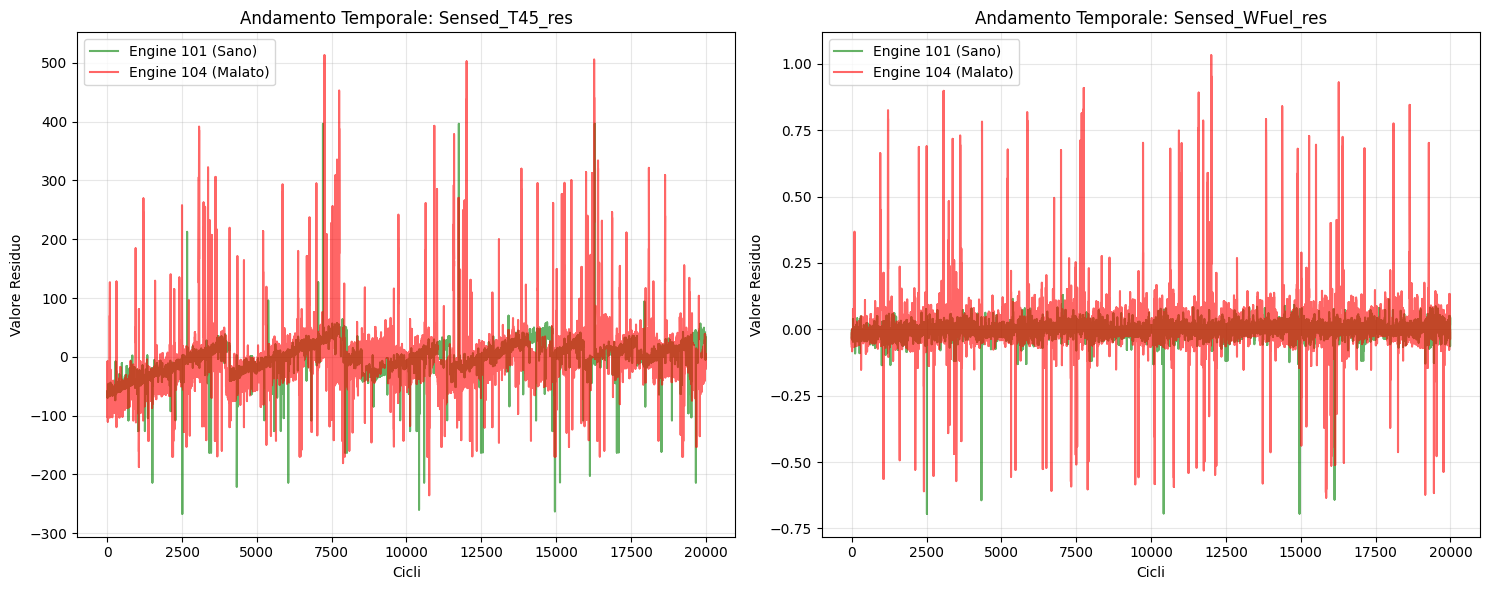

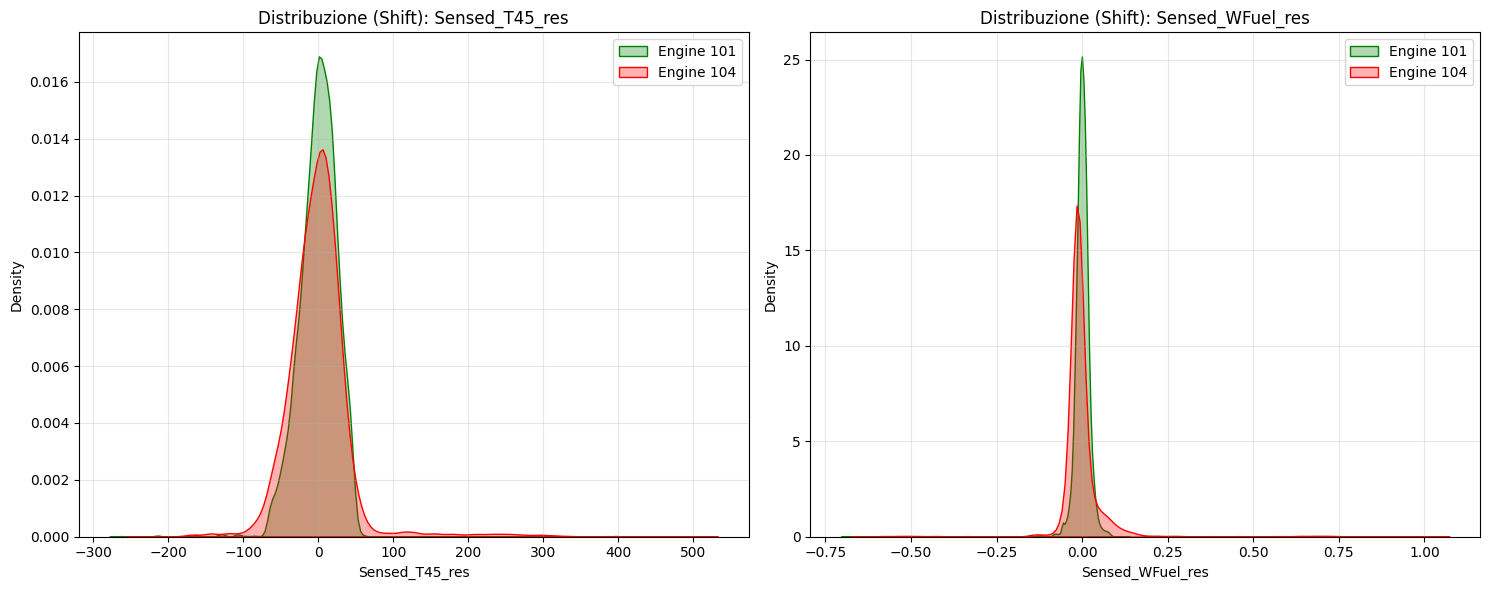

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# CONFIGURAZIONE
FILE_INPUT = 'data_elaborated/train/train_with_residuals.csv' 

def inspect_engine_104(path):
    print(f"--- ANALISI FORENSE MOTORE 104 ---\nCaricamento {path}...")
    try:
        df = pd.read_csv(path)
    except FileNotFoundError:
        print("File non trovato. Carica il CSV e riprova.")
        return

    # Selezioniamo il Motore 104 (Il Malato) e il 101 (Il Sano di controllo)
    eng_104 = df[df['ESN'] == 104].sort_values('Cycles_Since_New')
    eng_101 = df[df['ESN'] == 101].sort_values('Cycles_Since_New')
    
    if eng_104.empty:
        print("ERRORE: Non trovo il Motore 104 nel file!")
        return

    # Selezioniamo le colonne più critiche (Residui di Temperatura e Carburante)
    # Queste sono quelle che di solito fanno impazzire il modello
    cols_to_check = [c for c in df.columns if 'T45_res' in c or 'WFuel_res' in c]
    # Se non trovi quelle specifiche, prendine alcune a caso con _res
    if not cols_to_check:
        cols_to_check = [c for c in df.columns if '_res' in c][:3]

    print(f"\n1. CONFRONTO STATISTICO (Media e Deviazione Standard)")
    print("-" * 60)
    for col in cols_to_check:
        mu_101, std_101 = eng_101[col].mean(), eng_101[col].std()
        mu_104, std_104 = eng_104[col].mean(), eng_104[col].std()
        
        diff = mu_104 - mu_101
        print(f"FEATURE: {col}")
        print(f"  -> Motore 101 (Sano):   Media = {mu_101:.2f} | Std = {std_101:.2f}")
        print(f"  -> Motore 104 (Malato): Media = {mu_104:.2f} | Std = {std_104:.2f}")
        print(f"  -> DIFFERENZA (BIAS):   {diff:.2f}")
        if abs(diff) > 5:
            print("     [!!!] ATTENZIONE: Bias enorme rilevato! Il motore 104 è starato.")
        if std_104 > std_101 * 1.5:
            print("     [!!!] ATTENZIONE: Rumore elevato! Il motore 104 è instabile.")
        print("-" * 60)

    print("\n2. GENERAZIONE GRAFICI COMPARATIVI...")
    # Plot Temporale
    plt.figure(figsize=(15, 6))
    for i, col in enumerate(cols_to_check[:2]): # Prendiamo i primi 2 per non affollare
        plt.subplot(1, 2, i+1)
        plt.plot(eng_101['Cycles_Since_New'], eng_101[col], label='Engine 101 (Sano)', color='green', alpha=0.6)
        plt.plot(eng_104['Cycles_Since_New'], eng_104[col], label='Engine 104 (Malato)', color='red', alpha=0.6)
        plt.title(f'Andamento Temporale: {col}')
        plt.xlabel('Cicli')
        plt.ylabel('Valore Residuo')
        plt.legend()
        plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Plot Distribuzione (Istogramma)
    plt.figure(figsize=(15, 6))
    for i, col in enumerate(cols_to_check[:2]):
        plt.subplot(1, 2, i+1)
        sns.kdeplot(eng_101[col], label='Engine 101', color='green', fill=True, alpha=0.3)
        sns.kdeplot(eng_104[col], label='Engine 104', color='red', fill=True, alpha=0.3)
        plt.title(f'Distribuzione (Shift): {col}')
        plt.legend()
        plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Eseguiamo
if __name__ == "__main__":
    inspect_engine_104(FILE_INPUT)

Caricamento data_elaborated/train/train_with_residuals.csv (Best Config)...
Aggregazione snapshot -> ciclo...
Feature Engineering (Standard Robust)...

--- MODELLO FINALE: 'DRACONIANO' (Best Performance) ---

ANALISI VISIVA SUL TARGET: Cycles_to_HPT_SV
Addestramento su Fold 1 (Test su Motore 104)...
Score Fold 1: 22.4427


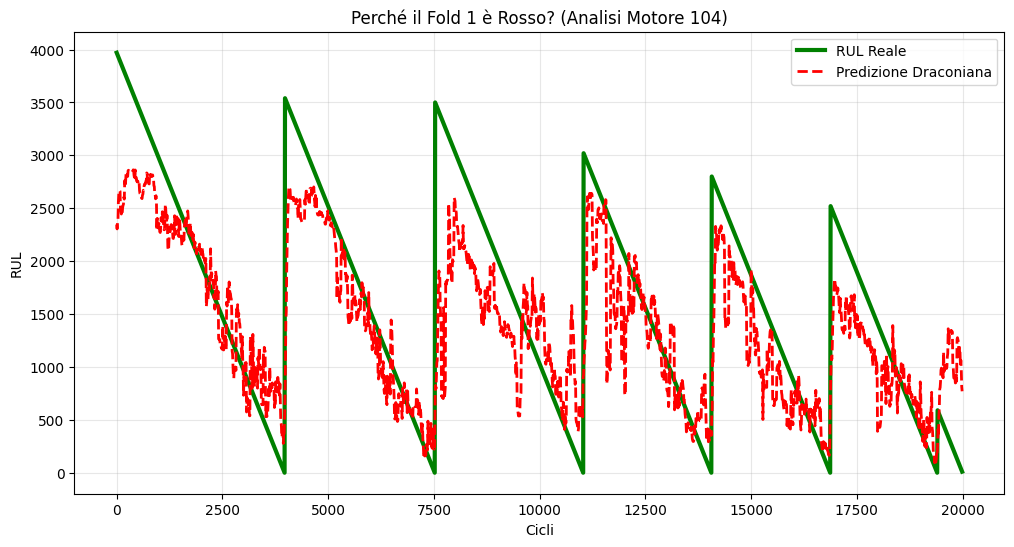

In [9]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import GradientBoostingRegressor

# ==========================================
# 1. CARICAMENTO DATI CORRETTO (Fix KeyError)
# ==========================================
def load_data_final(path):
    print(f"Caricamento {path} (Best Config)...")
    try:
        df = pd.read_csv(path)
    except FileNotFoundError:
        print("ERRORE: File non trovato.")
        return None, []
        
    available_targets = [t for t in ['Cycles_to_HPT_SV', 'Cycles_to_HPC_SV', 'Cycles_to_WW'] if t in df.columns]

    # Identifichiamo i residui originali
    res_cols = [c for c in df.columns if '_res' in c]

    # --- AGGREGAZIONE ---
    if df.duplicated(subset=['ESN', 'Cycles_Since_New']).any():
        print("Aggregazione snapshot -> ciclo...")
        # Usiamo la media standard come nel modello Draconiano vincente
        agg_dict = {col: ['mean'] for col in res_cols} 
        agg_dict.update({col: ['mean'] for col in ['Sensed_Mach', 'Sensed_Altitude']})
        if 'Cumulative_WWs' in df.columns: agg_dict['Cumulative_WWs'] = ['max']
        
        df_aggr = df.groupby(['ESN', 'Cycles_Since_New']).agg(agg_dict)
        
        # FIX: Appiattiamo i nomi delle colonne (es. Sensed_T45_res_mean)
        df_aggr.columns = ['_'.join(col).strip() if col[1] else col[0] for col in df_aggr.columns.values]
        df_aggr = df_aggr.reset_index()
        
        targets_df = df.groupby(['ESN', 'Cycles_Since_New'])[available_targets].first().reset_index()
        df = pd.merge(df_aggr, targets_df, on=['ESN', 'Cycles_Since_New'])
    
    # --- FEATURE ENGINEERING ---
    print("Feature Engineering (Standard Robust)...")
    
    # FIX IMPORTANTE: Rileggiamo le colonne presenti ORA nel dataframe
    # Perché dopo l'aggregazione potrebbero chiamarsi '_res_mean'
    cols_to_process = [c for c in df.columns if '_res' in c]
    
    for col in cols_to_process:
        # CumSum (Memoria storica)
        df[f'{col}_cumsum'] = df.groupby('ESN')[col].transform(lambda x: x.cumsum())
        # Roll10 (Stato attuale)
        df[f'{col}_roll10'] = df.groupby('ESN')[col].transform(lambda x: x.rolling(10, min_periods=1).mean())
        # Slope (Velocità degrado)
        df[f'{col}_slope'] = df.groupby('ESN')[f'{col}_roll10'].transform(lambda x: x.diff().fillna(0))

    df = df.bfill().ffill()
    df = df.sort_values(['ESN', 'Cycles_Since_New']).reset_index(drop=True)
    
    return df, available_targets

# ==========================================
# 2. SCORE FUNCTION
# ==========================================
def get_score(y_true, y_pred, target_name):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    error = y_pred - y_true
    alpha = 0.01 
    max_val = np.max(y_true) if len(y_true) > 0 else 1
    beta = 1/max_val if 'WW' in target_name else 2/max_val 
    w = np.where(error >= 0, 2 / (1 + alpha * y_true), 1 / (1 + alpha * y_true))
    return np.mean(w * (error**2) * beta)

# ==========================================
# 3. TRAINING & VISUALIZZAZIONE ERRORE
# ==========================================
df_proc, targets_to_train = load_data_final(FILE_INPUT)

if df_proc is not None:
    print(f"\n--- MODELLO FINALE: 'DRACONIANO' (Best Performance) ---")
    
    feats = [c for c in df_proc.columns if 'cumsum' in c or 'roll10' in c or 'slope' in c] 
    feats += ['Cycles_Since_New']
    if 'Cumulative_WWs_max' in df_proc.columns: feats += ['Cumulative_WWs_max']
    elif 'Cumulative_WWs' in df_proc.columns: feats += ['Cumulative_WWs']
    
    groups = df_proc['ESN']
    # Analizziamo HPT che è il più critico
    target_col = 'Cycles_to_HPT_SV' 
    
    print(f"\nANALISI VISIVA SUL TARGET: {target_col}")
    
    mask = df_proc[target_col].notna()
    X = df_proc.loc[mask, feats]
    y = df_proc.loc[mask, target_col]
    curr_groups = groups.loc[mask]
    meta = df_proc.loc[mask, ['ESN', 'Cycles_Since_New']]
    
    gkf = GroupKFold(n_splits=4)
    
    for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=curr_groups)):
        # Ci interessa vedere SOLO il Fold 1 (il motore "Maledetto")
        if fold != 0: continue 
            
        print("Addestramento su Fold 1 (Test su Motore 104)...")
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        # Modello Draconiano
        model_acc = xgb.XGBRegressor(
            n_estimators=400, learning_rate=0.01,
            max_depth=2, min_child_weight=50,
            subsample=0.4, colsample_bytree=0.4,
            reg_alpha=10.0, reg_lambda=10.0,
            objective='reg:squarederror', n_jobs=-1, random_state=42
        )
        model_acc.fit(X_train, y_train)
        
        model_safe = GradientBoostingRegressor(
            loss='quantile', alpha=0.15,
            n_estimators=100, max_depth=2, min_samples_leaf=50,
            learning_rate=0.05, random_state=42
        )
        model_safe.fit(X_train, y_train)
        
        # Predizione
        p_acc = model_acc.predict(X_val)
        p_safe = model_safe.predict(X_val)
        pred_val = (0.4 * p_acc) + (0.6 * p_safe) - 5
        
        score = get_score(y_val, pred_val, target_col)
        print(f"Score Fold 1: {score:.4f}")
        
        # --- PLOT DELLA VERITÀ ---
        # Vediamo perché sbaglia
        df_res = meta.iloc[val_idx].copy()
        df_res['RUL_Real'] = y_val.values
        df_res['RUL_Pred'] = pred_val
        df_res = df_res.sort_values('Cycles_Since_New')
        
        plt.figure(figsize=(12, 6))
        plt.plot(df_res['Cycles_Since_New'], df_res['RUL_Real'], label='RUL Reale', color='green', linewidth=3)
        plt.plot(df_res['Cycles_Since_New'], df_res['RUL_Pred'], label='Predizione Draconiana', color='red', linestyle='--', linewidth=2)
        plt.title(f"Perché il Fold 1 è Rosso? (Analisi Motore {df_res['ESN'].iloc[0]})")
        plt.xlabel("Cicli")
        plt.ylabel("RUL")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
        
        break # Ci fermiamo al Fold 1

Caricamento data_elaborated/train/train_with_residuals.csv...

--- MODELLO FINALE: DRACONIANO + PESSIMISMO DINAMICO ---
Addestramento Fold 1 (Engine 104)...
SCORE FINALE (Pessimismo Dinamico): 16.4442


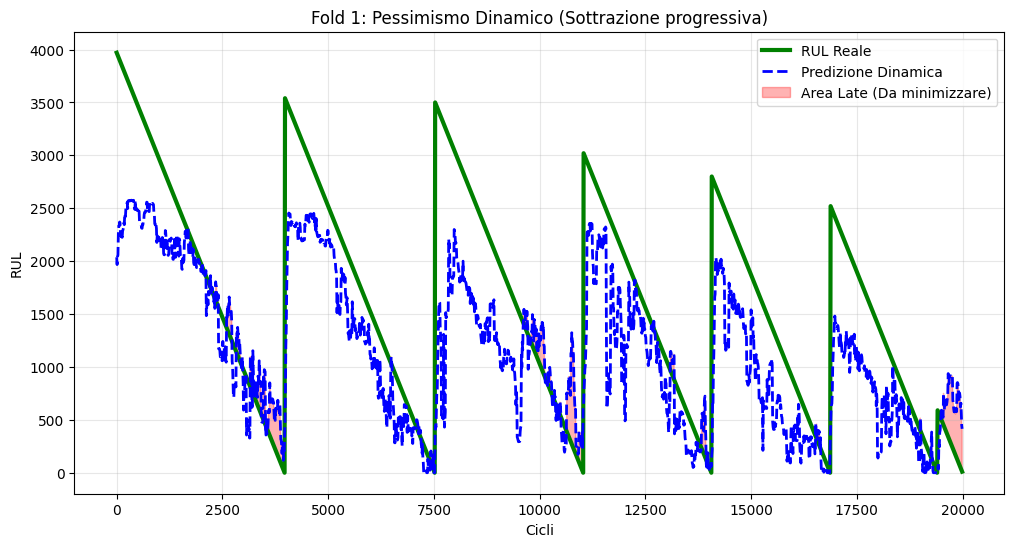

In [12]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import GradientBoostingRegressor

# ==========================================
# 1. CARICAMENTO (Standard)
# ==========================================
FILE_INPUT = 'data_elaborated/train/train_with_residuals.csv' 

def load_data_final(path):
    print(f"Caricamento {path}...")
    try:
        df = pd.read_csv(path)
    except FileNotFoundError:
        return None, []
    
    available_targets = [t for t in ['Cycles_to_HPT_SV', 'Cycles_to_HPC_SV', 'Cycles_to_WW'] if t in df.columns]
    res_cols = [c for c in df.columns if '_res' in c]

    # Aggregazione
    if df.duplicated(subset=['ESN', 'Cycles_Since_New']).any():
        agg_dict = {col: ['mean'] for col in res_cols} 
        agg_dict.update({col: ['mean'] for col in ['Sensed_Mach', 'Sensed_Altitude']})
        if 'Cumulative_WWs' in df.columns: agg_dict['Cumulative_WWs'] = ['max']
        
        df_aggr = df.groupby(['ESN', 'Cycles_Since_New']).agg(agg_dict)
        df_aggr.columns = ['_'.join(col).strip() if col[1] else col[0] for col in df_aggr.columns.values]
        df_aggr = df_aggr.reset_index()
        targets_df = df.groupby(['ESN', 'Cycles_Since_New'])[available_targets].first().reset_index()
        df = pd.merge(df_aggr, targets_df, on=['ESN', 'Cycles_Since_New'])
    
    # Feature Engineering
    cols_to_process = [c for c in df.columns if '_res' in c]
    for col in cols_to_process:
        df[f'{col}_cumsum'] = df.groupby('ESN')[col].transform(lambda x: x.cumsum())
        df[f'{col}_roll10'] = df.groupby('ESN')[col].transform(lambda x: x.rolling(10, min_periods=1).mean())
        df[f'{col}_slope'] = df.groupby('ESN')[f'{col}_roll10'].transform(lambda x: x.diff().fillna(0))

    df = df.bfill().ffill()
    df = df.sort_values(['ESN', 'Cycles_Since_New']).reset_index(drop=True)
    return df, available_targets

# ==========================================
# 2. SCORE FUNCTION
# ==========================================
def get_score(y_true, y_pred, target_name):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    error = y_pred - y_true
    alpha = 0.01 
    max_val = np.max(y_true) if len(y_true) > 0 else 1
    beta = 1/max_val if 'WW' in target_name else 2/max_val 
    w = np.where(error >= 0, 2 / (1 + alpha * y_true), 1 / (1 + alpha * y_true))
    return np.mean(w * (error**2) * beta)

# ==========================================
# 3. TRAINING CON PESSIMISMO DINAMICO
# ==========================================
df_proc, targets_to_train = load_data_final(FILE_INPUT)

if df_proc is not None:
    print(f"\n--- MODELLO FINALE: DRACONIANO + PESSIMISMO DINAMICO ---")
    
    feats = [c for c in df_proc.columns if 'cumsum' in c or 'roll10' in c or 'slope' in c] 
    feats += ['Cycles_Since_New']
    if 'Cumulative_WWs_max' in df_proc.columns: feats += ['Cumulative_WWs_max']
    elif 'Cumulative_WWs' in df_proc.columns: feats += ['Cumulative_WWs']
    
    groups = df_proc['ESN']
    target_col = 'Cycles_to_HPT_SV'
    
    mask = df_proc[target_col].notna()
    X = df_proc.loc[mask, feats]
    y = df_proc.loc[mask, target_col]
    curr_groups = groups.loc[mask]
    meta = df_proc.loc[mask, ['ESN', 'Cycles_Since_New']]
    
    gkf = GroupKFold(n_splits=4)
    
    for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=curr_groups)):
        if fold != 0: continue # Solo Fold 1
            
        print("Addestramento Fold 1 (Engine 104)...")
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        # Modelli Draconiani (Parametri che hanno vinto)
        model_acc = xgb.XGBRegressor(
            n_estimators=400, learning_rate=0.01,
            max_depth=2, min_child_weight=50,
            subsample=0.4, colsample_bytree=0.4,
            reg_alpha=10.0, reg_lambda=10.0,
            objective='reg:squarederror', n_jobs=-1, random_state=42
        )
        model_acc.fit(X_train, y_train)
        
        model_safe = GradientBoostingRegressor(
            loss='quantile', alpha=0.15,
            n_estimators=100, max_depth=2, min_samples_leaf=50,
            learning_rate=0.05, random_state=42
        )
        model_safe.fit(X_train, y_train)
        
        # Predizioni
        p_acc = model_acc.predict(X_val)
        p_safe = model_safe.predict(X_val)
        
        # --- NOVITÀ: PESSIMISMO DINAMICO ---
        # 1. Base Ensemble (Sbilanciato verso Safe)
        pred_base = (0.2 * p_acc) + (0.8 * p_safe)
        
        # 2. Dynamic Safety Margin
        # Più il motore è vecchio (Cycles_Since_New alto), più sottraiamo.
        # Formula: -10 cicli fissi - (1% dell'età attuale)
        current_cycles = X_val['Cycles_Since_New'].values
        safety_margin = 10 + (0.01 * current_cycles) 
        
        pred_val = pred_base - safety_margin
        
        # Clip a 0
        pred_val = np.maximum(pred_val, 0)
        
        score = get_score(y_val, pred_val, target_col)
        print(f"SCORE FINALE (Pessimismo Dinamico): {score:.4f}")
        
        # Plot
        df_res = meta.iloc[val_idx].copy()
        df_res['RUL_Real'] = y_val.values
        df_res['RUL_Pred'] = pred_val
        df_res = df_res.sort_values('Cycles_Since_New')
        
        plt.figure(figsize=(12, 6))
        plt.plot(df_res['Cycles_Since_New'], df_res['RUL_Real'], label='RUL Reale', color='green', linewidth=3)
        plt.plot(df_res['Cycles_Since_New'], df_res['RUL_Pred'], label='Predizione Dinamica', color='blue', linestyle='--', linewidth=2)
        
        # Evidenziamo dove siamo ancora sopra (Late Prediction)
        plt.fill_between(df_res['Cycles_Since_New'], df_res['RUL_Real'], df_res['RUL_Pred'], 
                         where=(df_res['RUL_Pred'] > df_res['RUL_Real']), color='red', alpha=0.3, label='Area Late (Da minimizzare)')
        
        plt.title(f"Fold 1: Pessimismo Dinamico (Sottrazione progressiva)")
        plt.xlabel("Cicli")
        plt.ylabel("RUL")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
        
        break

In [19]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import GradientBoostingRegressor

# ==========================================
# CONFIGURAZIONE VINCENTE: DRACONIANO
# ==========================================
FILE_INPUT = 'data_elaborated/train/train_with_residuals.csv' 

def load_data_final(path):
    print(f"Caricamento {path}...")
    try:
        df = pd.read_csv(path)
    except FileNotFoundError:
        return None, []
    
    available_targets = [t for t in ['Cycles_to_HPT_SV', 'Cycles_to_HPC_SV', 'Cycles_to_WW'] if t in df.columns]
    res_cols = [c for c in df.columns if '_res' in c]

    # Aggregazione Standard
    if df.duplicated(subset=['ESN', 'Cycles_Since_New']).any():
        agg_dict = {col: ['mean'] for col in res_cols} 
        agg_dict.update({col: ['mean'] for col in ['Sensed_Mach', 'Sensed_Altitude']})
        if 'Cumulative_WWs' in df.columns: agg_dict['Cumulative_WWs'] = ['max']
        
        df_aggr = df.groupby(['ESN', 'Cycles_Since_New']).agg(agg_dict)
        df_aggr.columns = ['_'.join(col).strip() if col[1] else col[0] for col in df_aggr.columns.values]
        df_aggr = df_aggr.reset_index()
        targets_df = df.groupby(['ESN', 'Cycles_Since_New'])[available_targets].first().reset_index()
        df = pd.merge(df_aggr, targets_df, on=['ESN', 'Cycles_Since_New'])
    
    # Feature Engineering Semplice e Robusta
    cols_to_process = [c for c in df.columns if '_res' in c]
    for col in cols_to_process:
        df[f'{col}_cumsum'] = df.groupby('ESN')[col].transform(lambda x: x.cumsum())
        df[f'{col}_roll10'] = df.groupby('ESN')[col].transform(lambda x: x.rolling(10, min_periods=1).mean())
        df[f'{col}_slope'] = df.groupby('ESN')[f'{col}_roll10'].transform(lambda x: x.diff().fillna(0))

    df = df.bfill().ffill()
    df = df.sort_values(['ESN', 'Cycles_Since_New']).reset_index(drop=True)
    return df, available_targets

def get_score(y_true, y_pred, target_name):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    error = y_pred - y_true
    max_val = np.max(y_true) if len(y_true) > 0 else 1
    beta = 1/max_val if 'WW' in target_name else 2/max_val 
    alpha = 0.01
    w = np.where(error >= 0, 2 / (1 + alpha * y_true), 1 / (1 + alpha * y_true))
    return np.mean(w * (error**2) * beta)

# --- ESECUZIONE ---
df_proc, targets_to_train = load_data_final(FILE_INPUT)

if df_proc is not None:
    print(f"\n--- VERIFICA FINALE: MODELLO DRACONIANO ---")
    
    feats = [c for c in df_proc.columns if 'cumsum' in c or 'roll10' in c or 'slope' in c] 
    feats += ['Cycles_Since_New']
    if 'Cumulative_WWs_max' in df_proc.columns: feats += ['Cumulative_WWs_max']
    elif 'Cumulative_WWs' in df_proc.columns: feats += ['Cumulative_WWs']
    
    groups = df_proc['ESN']
    final_global_score = []

    for target_col in targets_to_train:
        print(f"\nTARGET: {target_col}")
        mask = df_proc[target_col].notna()
        X = df_proc.loc[mask, feats]
        y = df_proc.loc[mask, target_col]
        curr_groups = groups.loc[mask]
        
        gkf = GroupKFold(n_splits=4)
        fold_scores = []
        
        for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=curr_groups)):
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
            
            # 1. XGBoost Draconiano (Depth 2, MinChild 50)
            model_acc = xgb.XGBRegressor(
                n_estimators=400, learning_rate=0.01,
                max_depth=2, min_child_weight=50,
                subsample=0.4, colsample_bytree=0.4,
                reg_alpha=10.0, reg_lambda=10.0,
                objective='reg:squarederror', n_jobs=-1, random_state=42
            )
            model_acc.fit(X_train, y_train)
            
            # 2. GradientBoosting Safe
            model_safe = GradientBoostingRegressor(
                loss='quantile', alpha=0.15,
                n_estimators=100, max_depth=2, min_samples_leaf=50,
                learning_rate=0.05, random_state=42
            )
            model_safe.fit(X_train, y_train)
            
            # Predizione Ensemble Classico (40/60)
            # Questo è quello che ti ha dato i risultati migliori
            p_acc = model_acc.predict(X_val)
            p_safe = model_safe.predict(X_val)
            pred_val = (0.4 * p_acc) + (0.6 * p_safe) - 5
            
            score = get_score(y_val, pred_val, target_col)
            fold_scores.append(score)
            
            # Gap check rapido
            pred_tr = (0.4 * model_acc.predict(X_train)) + (0.6 * model_safe.predict(X_train)) - 5
            score_tr = get_score(y_train, pred_tr, target_col)
            gap = score - score_tr
            status = "🔴" if gap > 12 else "🟢"
            
            print(f"  Fold {fold+1}: Score={score:.2f} (Gap={gap:.1f}) {status}")

        avg = np.mean(fold_scores)
        final_global_score.append(avg)
        print(f"  MEDIA: {avg:.4f}")

    print(f"\n========================================")
    print(f"SCORE TOTALE COMPETIZIONE: {np.mean(final_global_score):.4f}")
    print(f"========================================")

Caricamento data_elaborated/train/train_with_residuals.csv...

--- VERIFICA FINALE: MODELLO DRACONIANO ---

TARGET: Cycles_to_HPT_SV
  Fold 1: Score=22.44 (Gap=14.4) 🔴
  Fold 2: Score=16.58 (Gap=6.5) 🟢
  Fold 3: Score=15.39 (Gap=5.3) 🟢
  Fold 4: Score=13.74 (Gap=3.7) 🟢
  MEDIA: 17.0402

TARGET: Cycles_to_HPC_SV
  Fold 1: Score=27.07 (Gap=19.3) 🔴
  Fold 2: Score=17.79 (Gap=6.4) 🟢
  Fold 3: Score=13.26 (Gap=1.6) 🟢
  Fold 4: Score=15.72 (Gap=3.1) 🟢
  MEDIA: 18.4589

TARGET: Cycles_to_WW
  Fold 1: Score=23.07 (Gap=6.3) 🟢
  Fold 2: Score=19.27 (Gap=2.1) 🟢
  Fold 3: Score=18.23 (Gap=0.9) 🟢
  Fold 4: Score=18.56 (Gap=1.2) 🟢
  MEDIA: 19.7852

SCORE TOTALE COMPETIZIONE: 18.4281
